# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Step 1. Load the data

In [3]:
df = pd.read_csv(r"C:\Users\Renad\Downloads\Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
print(df.head())

   Hours_Studied  Marks
0           4.76  46.27
1           3.00  34.30
2           2.08  33.63
3           4.04  47.81
4           9.49  66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [8]:
X = df[['Hours_Studied']]
y = df['Marks']

### Step 2.b print the type of each

In [9]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [10]:
target_dtype = y.dtype

print(f"Target data type: {target_dtype}")

if pd.api.types.is_numeric_dtype(y):
    print("The target is: Numerical")
    print("The task is: Regression")
else:
    print("The target is: Categorical")
    print("The task is: Classification")

Target data type: float64
The target is: Numerical
The task is: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [11]:
print(f"X shape: {X.shape}") 
print(f"y shape: {y.shape}") 

X shape: (100, 1)
y shape: (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [12]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

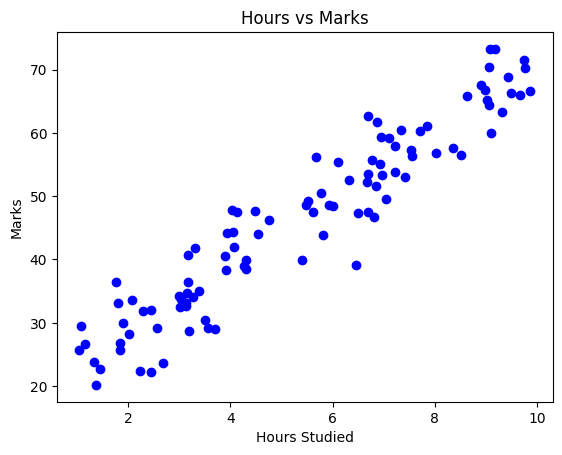

In [14]:
plt.scatter(X, y, color='blue')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Hours vs Marks')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [15]:
correlation = df['Hours_Studied'].corr(df['Marks'])
print(f"Correlation Coefficient: {correlation}")

if correlation > 0:
    print("The relationship is Increasing (Positive)")
elif correlation < 0:
    print("The relationship is Decreasing (Negative)")
else:
    print("No relationship")

Correlation Coefficient: 0.9489736438661722
The relationship is Increasing (Positive)


### Step 7. Initialize a `LinearRegression` model

In [16]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Train the model on the training set

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [21]:
slope = model.coef_[0]
intercept = model.intercept_ 

print(f"Learned Slope (m): {slope}")
print(f"Y-intercept (b): {intercept}")

Learned Slope (m): 5.164438413499556
Y-intercept (b): 18.538578512317276


### Step 9.c how much marks do we get per 1 hour of study?

In [22]:
marks_per_hour = model.coef_[0]

print(f"We get approximately {marks_per_hour:.2f} marks for every 1 hour of study.")

We get approximately 5.16 marks for every 1 hour of study.


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [23]:
increase_10_min = slope / 6
print(f"Extra marks for 10 minutes: {increase_10_min}")

Extra marks for 10 minutes: 0.8607397355832593


### Step 9.e if one doesn't study at all, how much marks do they get?

In [24]:
zero_study_marks = model.intercept_

print(f"If a student studies 0 hours, they are expected to get: {zero_study_marks:.2f} marks.")

If a student studies 0 hours, they are expected to get: 18.54 marks.


### Step 10. Evaluate the model on the test set

In [25]:
accuracy = model.score(X_test, y_test)

print(f"Model Accuracy (R^2 Score): {accuracy:.4f}")

Model Accuracy (R^2 Score): 0.9258


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [26]:
X_sample = X_test.head(3)
y_true = y_test.head(3)

y_pred = model.predict(X_sample)

comparison = pd.DataFrame({
    'Hours Studied': X_sample.values.flatten(),
    'Actual Marks': y_true.values,
    'Predicted Marks': y_pred
})

print(comparison)

   Hours Studied  Actual Marks  Predicted Marks
0           3.02         32.50        34.135183
1           8.90         67.54        64.502080
2           6.78         55.70        53.553471


### Step 12. Plot the data and the regression line

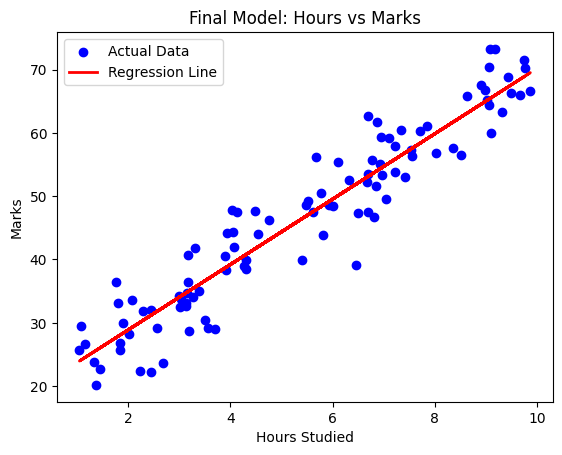

In [27]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Final Model: Hours vs Marks')
plt.legend()
plt.show()